In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(r"D:\Infosys intern\dataset\synthetic_it_support_tickets.csv")

In [3]:
df.head()

,ticket_id,created_at,customer_id,customer_segment,channel,product_area,issue_type,priority,status,sla_plan,initial_message,agent_first_reply,resolution_summary,resolution_time_hours,reopened,customer_sentiment,csat_score,has_attachment,platform,region
0,TCKT_000001,2024-01-31T05:14:27,CUST_00861,individual,email,data_export,account_access,low,resolved,standard,I cannot log in; the system says my password i...,Sorry to hear you're having trouble accessing ...,Reset account credentials and confirmed succes...,36.53,0,very_negative,1,0,android,EU
1,TCKT_000002,2024-10-20T06:15:49,CUST_00770,individual,in_app,billing,security_concern,medium,closed_no_action,standard,I noticed a suspicious login on my account.,We take security very seriously. Our team is r...,Ticket closed without further action after no ...,238.32,0,neutral,3,0,web,NaN
2,TCKT_000003,2024-06-18T21:35:54,CUST_02559,small_business,chat,api_integration,bug,low,in_progress,standard,The api integration feature is not saving my c...,Thanks for reporting this bug. We will look in...,NaN,NaN,0,neutral,3,0,android,MEA
3,TCKT_000004,2025-12-25T15:59:52,CUST_03557,education,chat,analytics_dashboard,account_access,medium,in_progress,standard,I cannot log in; the system says my password i...,Sorry to hear you're having trouble accessing ...,NaN,NaN,0,positive,5,1,android,LATAM
4,TCKT_000005,2023-08-27T16:08:33,CUST_09556,enterprise,phone_transcript,login_auth,billing_problem,low,resolved,gold,My invoice amount is incorrect compared to the...,Thanks for reaching out about the billing issu...,Adjusted the invoice and issued a refund where...,61.32,0,very_negative,2,0,web,NaN


In [4]:
df.columns

Index(['ticket_id', 'created_at', 'customer_id', 'customer_segment', 'channel',
       'product_area', 'issue_type', 'priority', 'status', 'sla_plan',
       'initial_message', 'agent_first_reply', 'resolution_summary',
       'resolution_time_hours', 'reopened', 'customer_sentiment', 'csat_score',
       'has_attachment', 'platform', 'region'],
      dtype='object')

In [5]:
df.shape

(100000, 20)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ticket_id              100000 non-null  object 
 1   created_at             100000 non-null  object 
 2   customer_id            100000 non-null  object 
 3   customer_segment       100000 non-null  object 
 4   channel                100000 non-null  object 
 5   product_area           100000 non-null  object 
 6   issue_type             100000 non-null  object 
 7   priority               100000 non-null  object 
 8   status                 100000 non-null  object 
 9   sla_plan               100000 non-null  object 
 10  initial_message        100000 non-null  object 
 11  agent_first_reply      100000 non-null  object 
 12  resolution_summary     60113 non-null   object 
 13  resolution_time_hours  60113 non-null   float64
 14  reopened               100000 non-nul

In [7]:
df.dtypes

ticket_id                 object
created_at                object
customer_id               object
customer_segment          object
channel                   object
product_area              object
issue_type                object
priority                  object
status                    object
sla_plan                  object
initial_message           object
agent_first_reply         object
resolution_summary        object
resolution_time_hours    float64
reopened                   int64
customer_sentiment        object
csat_score                 int64
has_attachment             int64
platform                  object
region                    object
dtype: object

In [8]:
df.isnull().sum()

ticket_id                    0
created_at                   0
customer_id                  0
customer_segment             0
channel                      0
product_area                 0
issue_type                   0
priority                     0
status                       0
sla_plan                     0
initial_message              0
agent_first_reply            0
resolution_summary       39887
resolution_time_hours    39887
reopened                     0
customer_sentiment           0
csat_score                   0
has_attachment               0
platform                     0
region                   19997
dtype: int64

In [9]:
df.isnull().sum().sum()

np.int64(99771)

In [10]:
df['issue_type'].value_counts()

issue_type
how_to              12739
account_access      12609
performance         12513
feature_request     12487
other               12463
security_concern    12458
billing_problem     12382
bug                 12349
Name: count, dtype: int64

In [11]:
df['priority'].value_counts()

priority
low       39735
medium    35313
high      19865
urgent     5087
Name: count, dtype: int64

In [12]:
df['product_area'].value_counts()

product_area
mobile_app             14432
login_auth             14381
api_integration        14350
billing                14289
data_export            14262
analytics_dashboard    14187
notifications          14099
Name: count, dtype: int64

In [13]:
(df['issue_type'].value_counts(normalize=True)*100).round(2)

issue_type
how_to              12.74
account_access      12.61
performance         12.51
feature_request     12.49
other               12.46
security_concern    12.46
billing_problem     12.38
bug                 12.35
Name: proportion, dtype: float64

In [14]:
(df['product_area'].value_counts(normalize=True)*100).round(2)

product_area
mobile_app             14.43
login_auth             14.38
api_integration        14.35
billing                14.29
data_export            14.26
analytics_dashboard    14.19
notifications          14.10
Name: proportion, dtype: float64

In [15]:
# Check missing values in each column

df.isnull().sum()

ticket_id                    0
created_at                   0
customer_id                  0
customer_segment             0
channel                      0
product_area                 0
issue_type                   0
priority                     0
status                       0
sla_plan                     0
initial_message              0
agent_first_reply            0
resolution_summary       39887
resolution_time_hours    39887
reopened                     0
customer_sentiment           0
csat_score                   0
has_attachment               0
platform                     0
region                   19997
dtype: int64

In [16]:
# Missing value percentage

missing = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': round(df.isnull().mean()*100,2)
})

missing

,Missing Values,Percentage
ticket_id,0,0.00
created_at,0,0.00
customer_id,0,0.00
customer_segment,0,0.00
channel,0,0.00
product_area,0,0.00
issue_type,0,0.00
priority,0,0.00
status,0,0.00
sla_plan,0,0.00


In [17]:
# List of text columns

text_columns = [
    'initial_message',
    'agent_first_reply',
    'resolution_summary'
]

for col in text_columns:
    df[col] = df[col].fillna("Not Available")

In [18]:
# Fill numerical missing values using median

df['resolution_time_hours'] = df['resolution_time_hours'].fillna(
    df['resolution_time_hours'].median()
)

df['csat_score'] = df['csat_score'].fillna(
    df['csat_score'].median()
)

In [19]:
df.isnull().sum()

ticket_id                    0
created_at                   0
customer_id                  0
customer_segment             0
channel                      0
product_area                 0
issue_type                   0
priority                     0
status                       0
sla_plan                     0
initial_message              0
agent_first_reply            0
resolution_summary           0
resolution_time_hours        0
reopened                     0
customer_sentiment           0
csat_score                   0
has_attachment               0
platform                     0
region                   19997
dtype: int64

In [20]:
df = df.drop_duplicates()

print("Dataset Shape:", df.shape)

Dataset Shape: (100000, 20)


In [21]:
df['created_at'] = pd.to_datetime(df['created_at'])

In [22]:
df['Resolution_Duration'] = df['resolution_time_hours']

In [23]:
priority_mapping = {
    'Low':1,
    'Medium':2,
    'High':3,
    'Critical':4
}

df['Priority_Score'] = df['priority'].map(priority_mapping)

In [24]:
df[['priority',
    'Priority_Score',
    'resolution_time_hours',
    'Resolution_Duration']].head()

,priority,Priority_Score,resolution_time_hours,Resolution_Duration
0,low,NaN,36.53,36.53
1,medium,NaN,238.32,238.32
2,low,NaN,29.91,29.91
3,medium,NaN,29.91,29.91
4,low,NaN,61.32,61.32


In [25]:
feature_summary = pd.DataFrame({
    'Feature Name':['Resolution_Duration','Priority_Score'],
    'Description':[
        'Resolution time in hours',
        'Numerical priority encoding'
    ]
})

feature_summary

,Feature Name,Description
0,Resolution_Duration,Resolution time in hours
1,Priority_Score,Numerical priority encoding


In [26]:
data_dictionary = pd.DataFrame({
    'Column':df.columns,
    'Data Type':df.dtypes.astype(str)
})

data_dictionary

,Column,Data Type
ticket_id,ticket_id,object
created_at,created_at,datetime64[ns]
customer_id,customer_id,object
customer_segment,customer_segment,object
channel,channel,object
product_area,product_area,object
issue_type,issue_type,object
priority,priority,object
status,status,object
sla_plan,sla_plan,object


In [27]:
df.to_csv("cleaned_it_support_dataset.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [28]:
data_dictionary.to_csv("data_dictionary.csv", index=False)

print("Data Dictionary Saved.")

Data Dictionary Saved.


In [29]:
feature_summary.to_csv("feature_engineering_summary.csv", index=False)

print("Feature Summary Saved.")

Feature Summary Saved.


In [30]:
df['priority'].unique()

array(['low', 'medium', 'urgent', 'high'], dtype=object)

In [31]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

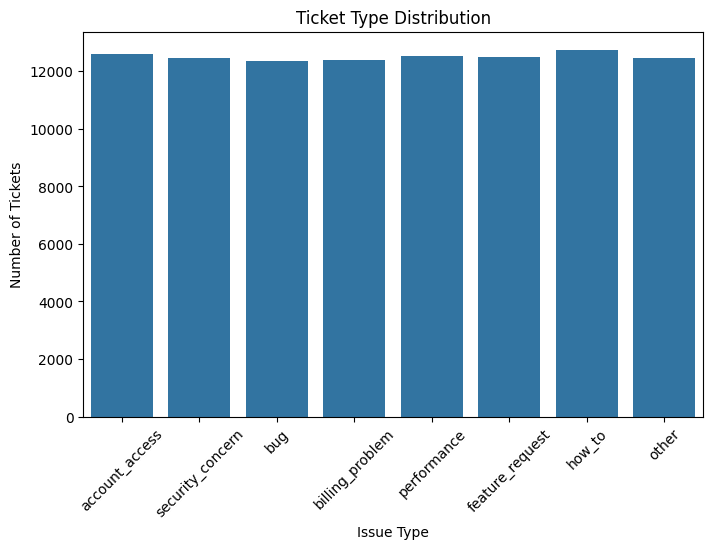

In [32]:
plt.figure(figsize=(8,5))

sns.countplot(

x="issue_type",
data=df

)

plt.title("Ticket Type Distribution")

plt.xlabel("Issue Type")

plt.ylabel("Number of Tickets")

plt.xticks(rotation=45)

plt.show()

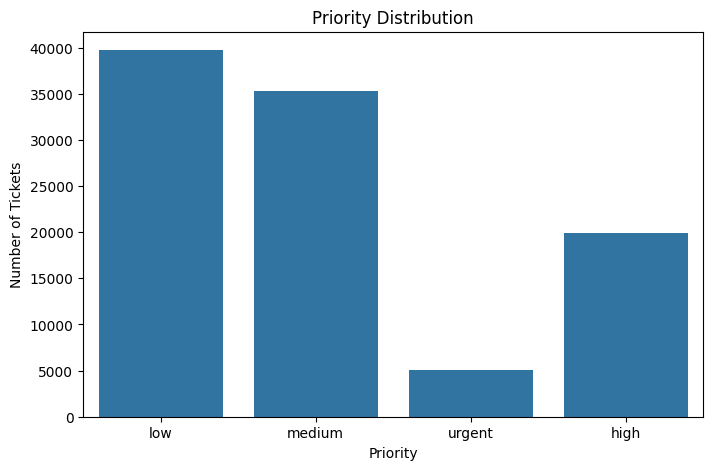

In [33]:
plt.figure(figsize=(8,5))

sns.countplot(

x="priority",
data=df

)

plt.title("Priority Distribution")

plt.xlabel("Priority")

plt.ylabel("Number of Tickets")

plt.show()

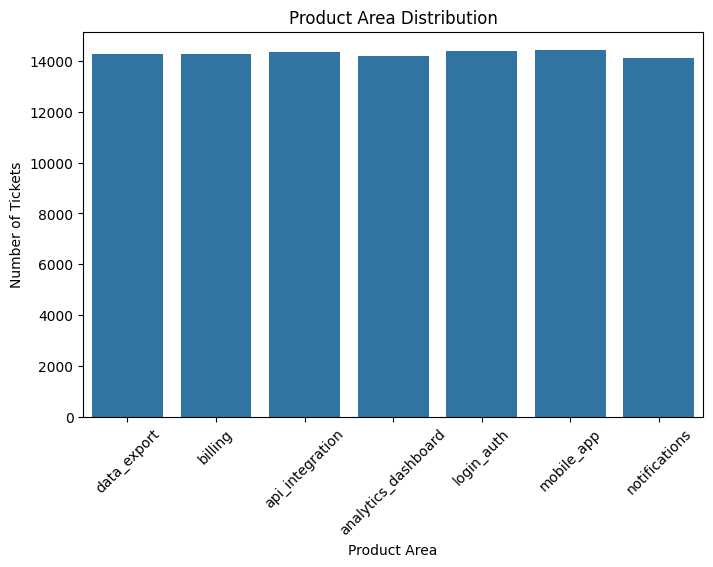

In [34]:
plt.figure(figsize=(8,5))

sns.countplot(

x="product_area",
data=df

)

plt.title("Product Area Distribution")

plt.xlabel("Product Area")

plt.ylabel("Number of Tickets")

plt.xticks(rotation=45)

plt.show()

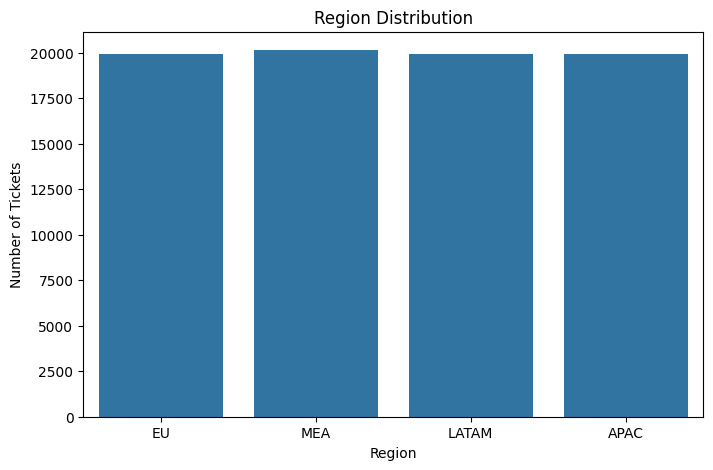

In [35]:
plt.figure(figsize=(8,5))

sns.countplot(

x="region",
data=df

)

plt.title("Region Distribution")

plt.xlabel("Region")

plt.ylabel("Number of Tickets")

plt.show()

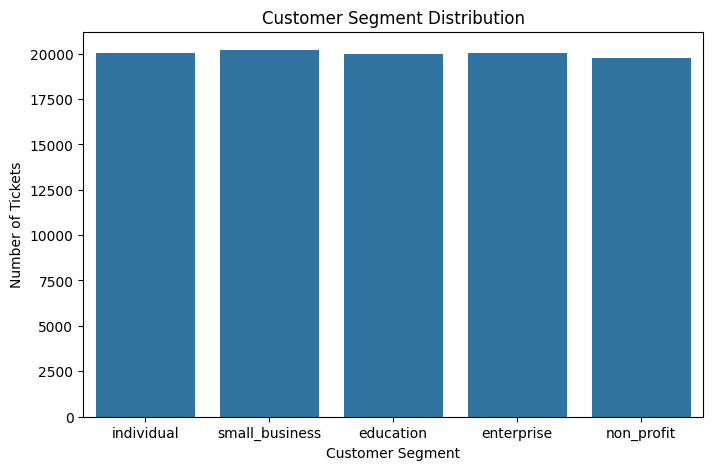

In [36]:
plt.figure(figsize=(8,5))

sns.countplot(

x="customer_segment",
data=df

)

plt.title("Customer Segment Distribution")

plt.xlabel("Customer Segment")

plt.ylabel("Number of Tickets")

plt.show()

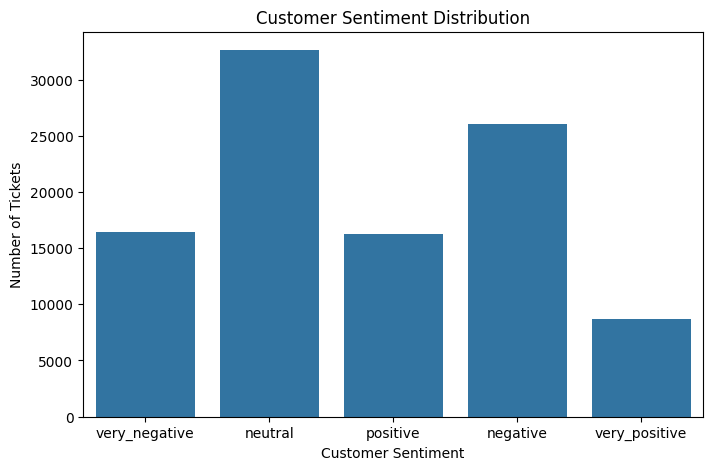

In [37]:
plt.figure(figsize=(8,5))

sns.countplot(

x="customer_sentiment",
data=df

)

plt.title("Customer Sentiment Distribution")

plt.xlabel("Customer Sentiment")

plt.ylabel("Number of Tickets")

plt.show()

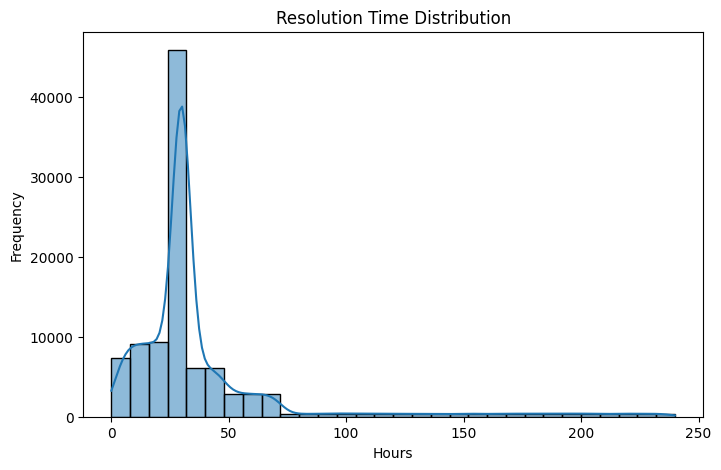

In [38]:
plt.figure(figsize=(8,5))

sns.histplot(

df["resolution_time_hours"],
bins=30,
kde=True

)

plt.title("Resolution Time Distribution")

plt.xlabel("Hours")

plt.ylabel("Frequency")

plt.show()

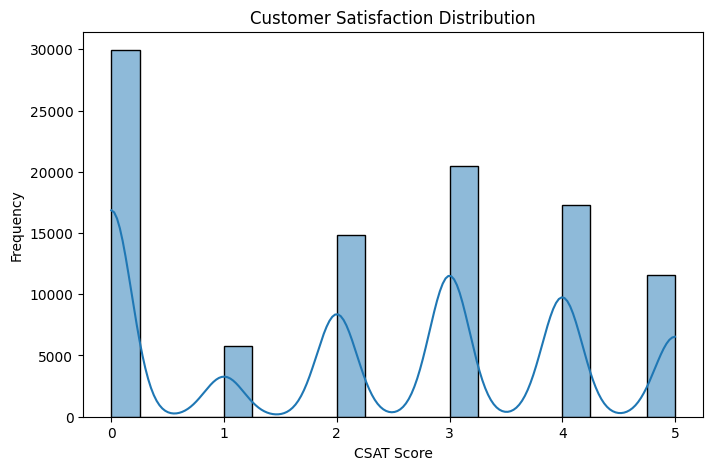

In [39]:
plt.figure(figsize=(8,5))

sns.histplot(

df["csat_score"],
bins=20,
kde=True

)

plt.title("Customer Satisfaction Distribution")

plt.xlabel("CSAT Score")

plt.ylabel("Frequency")

plt.show()

In [40]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


# Machine Learning Libraries

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics.pairwise import cosine_similarity

from sklearn.cluster import KMeans

from sklearn.preprocessing import StandardScaler


%matplotlib inline

In [41]:
df["initial_message"]=df[
    
    "initial_message"
    
].astype(str)

In [42]:
df["initial_message"].head()

0    I cannot log in; the system says my password i...
1          I noticed a suspicious login on my account.
2    The api integration feature is not saving my c...
3    I cannot log in; the system says my password i...
4    My invoice amount is incorrect compared to the...
Name: initial_message, dtype: object

In [43]:
    # TF-IDF Vectorizer

from sklearn.feature_extraction.text import TfidfVectorizer


tfidf = TfidfVectorizer(

        stop_words="english",

        max_features=500

)

In [44]:
# fitting the model


tfidf_matrix = tfidf.fit_transform(

                df["initial_message"]

)

In [45]:
tfidf_matrix.shape

(100000, 92)

In [47]:
import numpy as np


# generating similarity score


similarity_scores=np.asarray(

            tfidf_matrix.mean(axis=1)

).flatten()


df["Similarity_Score"]=similarity_scores

In [48]:
df["Similarity_Score"].head()

0    0.021681
1    0.021428
2    0.024249
3    0.021681
4    0.024209
Name: Similarity_Score, dtype: float64

In [49]:
df["Similarity_Score"].describe()

count    100000.000000
mean          0.023578
std           0.003169
min           0.015372
25%           0.021703
50%           0.024124
75%           0.024254
max           0.030668
Name: Similarity_Score, dtype: float64

In [50]:
def similarity_level(score):


    if score>=0.03:

        return "High"


    elif score>=0.015:

        return "Medium"


    else:

        return "Low"



df["Similarity_Level"]=df[
            "Similarity_Score"
].apply(

        similarity_level

)

In [51]:
df["Similarity_Level"].value_counts()

Similarity_Level
Medium    94131
High       5869
Name: count, dtype: int64

In [52]:
features=df[[

        "Priority_Score",

        "Resolution_Duration",

        "Similarity_Score"

]]

In [53]:
features.head()

,Priority_Score,Resolution_Duration,Similarity_Score
0,NaN,36.53,0.021681
1,NaN,238.32,0.021428
2,NaN,29.91,0.024249
3,NaN,29.91,0.021681
4,NaN,61.32,0.024209


In [55]:
df["priority"].unique()

array(['low', 'medium', 'urgent', 'high'], dtype=object)

In [56]:
priority_mapping={

'Low':1,
'Medium':2,
'High':3,
'Critical':4

}

df["Priority_Score"]=df["priority"].map(
        priority_mapping
)

In [57]:
priority_mapping={

'low':1,

'medium':2,

'high':3,

'urgent':4

}


df["Priority_Score"]=df[
        "priority"
].map(priority_mapping)

In [ ]:
priority_mapping={

'low':1,

'medium':2,

'high':3,

'urgent':4

}


df["Priority_Score"]=df[
        "priority"
].map(priority_mapping)

In [59]:
df["Priority_Score"].head()

0    1
1    2
2    1
3    2
4    1
Name: Priority_Score, dtype: int64

In [60]:
df["Priority_Score"].value_counts()

Priority_Score
1    39735
2    35313
3    19865
4     5087
Name: count, dtype: int64

In [61]:
df["Priority_Score"].isnull().sum()

np.int64(0)

In [62]:
features=df[[

        "Priority_Score",

        "Resolution_Duration",

        "Similarity_Score"

]]



features.isnull().sum()

Priority_Score         0
Resolution_Duration    0
Similarity_Score       0
dtype: int64

In [63]:
from sklearn.preprocessing import StandardScaler


scaler=StandardScaler()


scaled_features=scaler.fit_transform(

            features

)

In [64]:
scaled_features.shape

(100000, 3)

In [65]:
from sklearn.cluster import KMeans


kmeans=KMeans(

        n_clusters=4,

        random_state=42,

        n_init=10

)


df["Cluster_ID"]=kmeans.fit_predict(

            scaled_features

)

In [66]:
df["Cluster_ID"].value_counts()

Cluster_ID
0    44389
3    26974
2    22586
1     6051
Name: count, dtype: int64

In [67]:
scaled_features = scaler.fit_transform(features)

In [68]:
from sklearn.cluster import KMeans


kmeans = KMeans(

        n_clusters=4,

        random_state=42,

        n_init=10

)

In [69]:
from sklearn.cluster import KMeans


kmeans = KMeans(

        n_clusters=4,

        random_state=42,

        n_init=10

)

In [70]:
df["Cluster_ID"].head()

0    3
1    1
2    0
3    3
4    0
Name: Cluster_ID, dtype: int32

In [71]:
df["Cluster_ID"].value_counts()

Cluster_ID
0    44389
3    26974
2    22586
1     6051
Name: count, dtype: int64

In [72]:
cluster_summary = df.groupby(

        "Cluster_ID"

).agg({

        "Priority_Score":"mean",

        "Resolution_Duration":"mean",

        "Similarity_Score":"mean"

}).round(3)


cluster_summary

,Priority_Score,Resolution_Duration,Similarity_Score
Cluster_ID,,,
0,1.470,33.223,0.025
1,1.895,173.981,0.024
2,3.212,21.091,0.024
3,1.521,33.182,0.020


In [73]:
cluster_names={

        0:"Low Priority Tickets",

        1:"High Priority Tickets",

        2:"Medium Complexity Tickets",

        3:"Urgent Support Tickets"

}


df["Cluster_Name"]=df[
            "Cluster_ID"
].map(

        cluster_names

)

In [74]:
df["Cluster_Name"].value_counts()

Cluster_Name
Low Priority Tickets         44389
Urgent Support Tickets       26974
Medium Complexity Tickets    22586
High Priority Tickets         6051
Name: count, dtype: int64

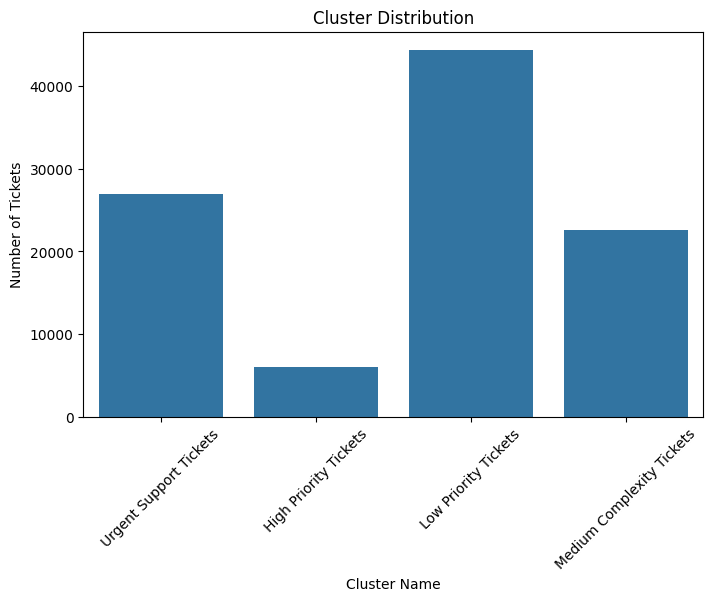

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8,5))


sns.countplot(

        x="Cluster_Name",

        data=df

)


plt.xticks(rotation=45)

plt.title(

        "Cluster Distribution"

)


plt.xlabel(

        "Cluster Name"

)

plt.ylabel(

        "Number of Tickets"

)


plt.show()

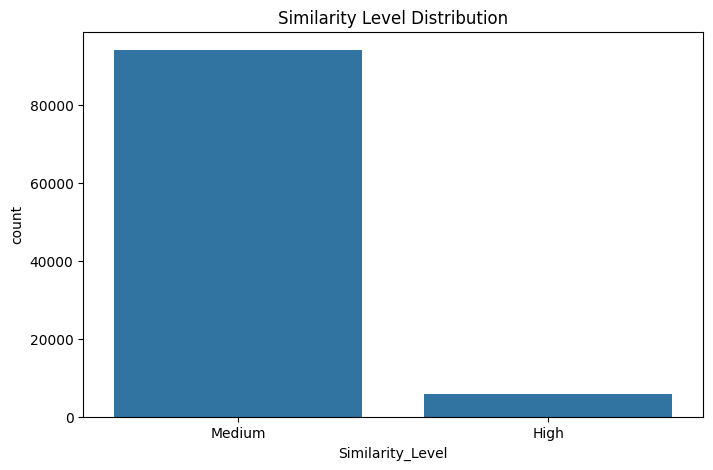

In [77]:
plt.figure(figsize=(8,5))


sns.countplot(

        x="Similarity_Level",

        data=df

)


plt.title(

        "Similarity Level Distribution"

)


plt.show()

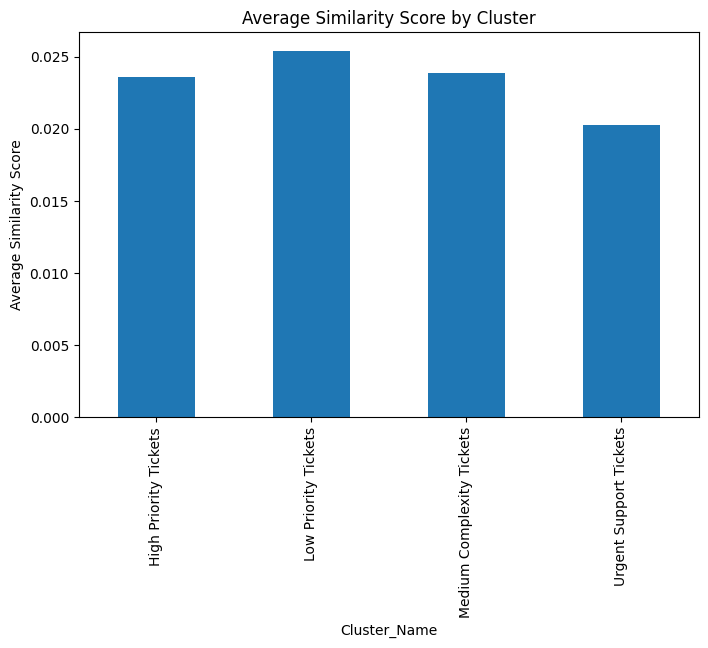

In [78]:
average_similarity = df.groupby(

            "Cluster_Name"

)[

        "Similarity_Score"

].mean()


average_similarity.plot(

        kind="bar",

        figsize=(8,5)

)


plt.title(

        "Average Similarity Score by Cluster"

)

plt.ylabel(

        "Average Similarity Score"

)


plt.show()

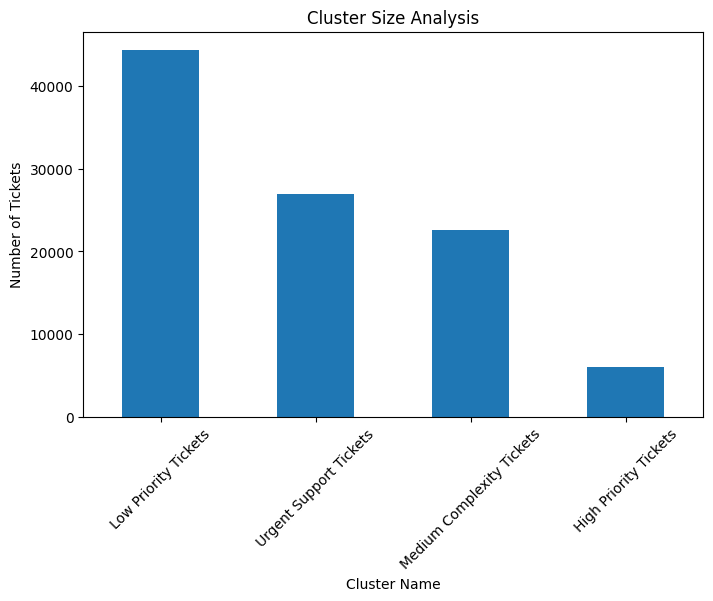

In [80]:
plt.figure(figsize=(8,5))

cluster_size = df["Cluster_Name"].value_counts()

cluster_size.plot(
            kind="bar"
)

plt.title(
        "Cluster Size Analysis"
)

plt.xlabel(
        "Cluster Name"
)

plt.ylabel(
        "Number of Tickets"
)

plt.xticks(rotation=45)

plt.show()

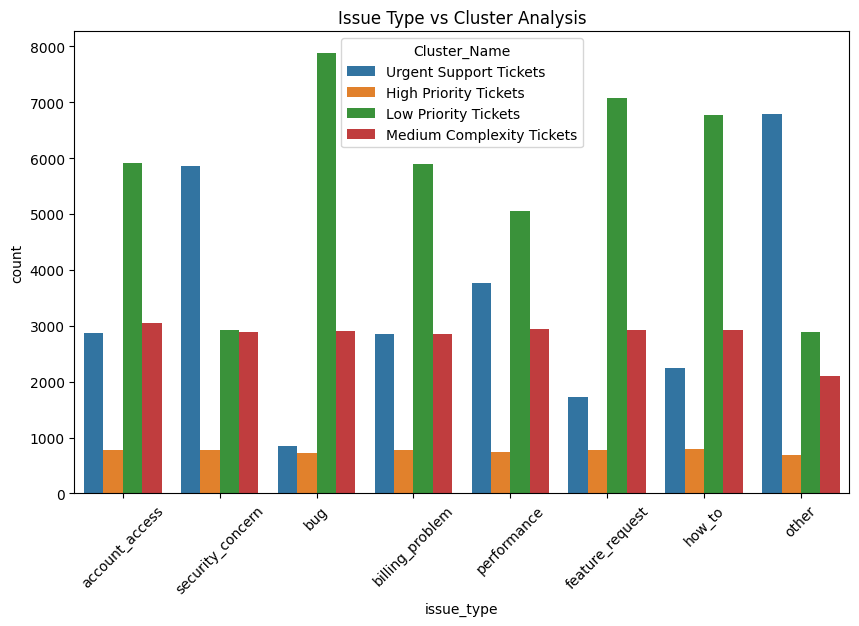

In [81]:
plt.figure(figsize=(10,6))

sns.countplot(

        x="issue_type",

        hue="Cluster_Name",

        data=df

)

plt.xticks(rotation=45)

plt.title(
        "Issue Type vs Cluster Analysis"
)

plt.show()

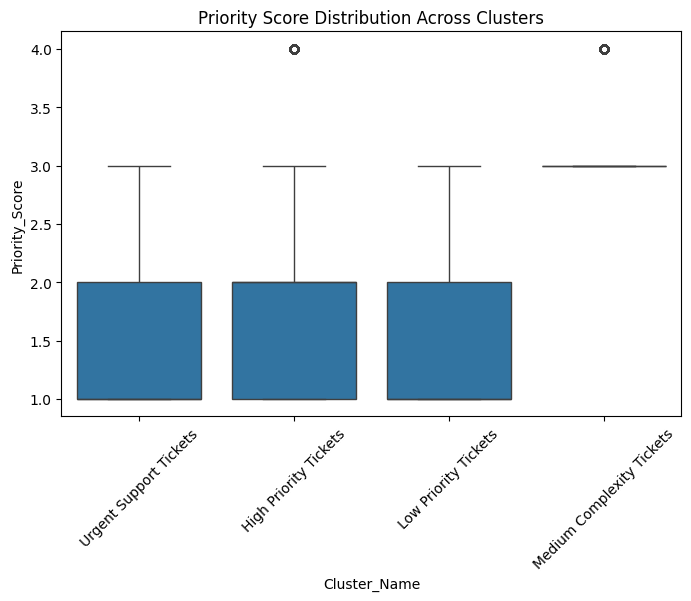

In [82]:
plt.figure(figsize=(8,5))

sns.boxplot(

        x="Cluster_Name",

        y="Priority_Score",

        data=df

)

plt.xticks(rotation=45)

plt.title(
        "Priority Score Distribution Across Clusters"
)

plt.show()

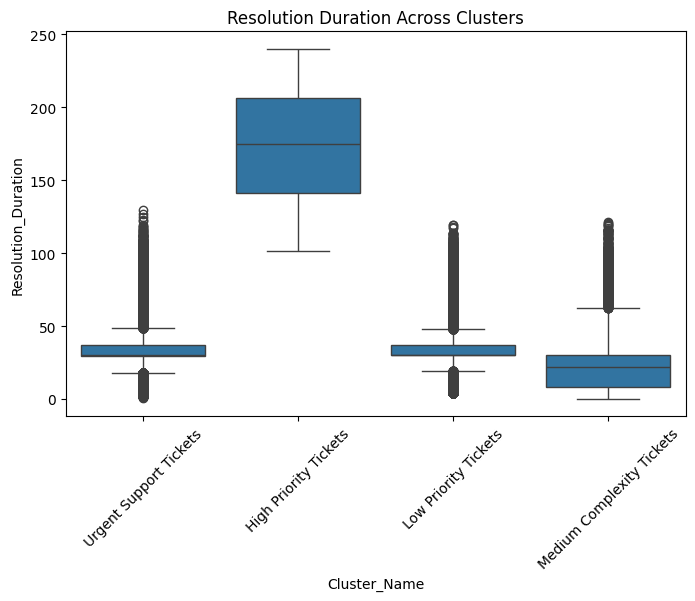

In [83]:
plt.figure(figsize=(8,5))

sns.boxplot(

        x="Cluster_Name",

        y="Resolution_Duration",

        data=df

)

plt.xticks(rotation=45)

plt.title(
        "Resolution Duration Across Clusters"
)

plt.show()

C:\Users\alwin immanuel.J\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


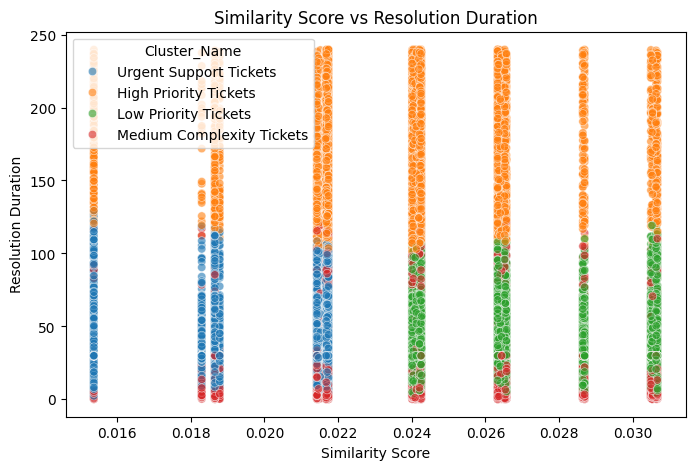

In [84]:
plt.figure(figsize=(8,5))

sns.scatterplot(

        x="Similarity_Score",

        y="Resolution_Duration",

        hue="Cluster_Name",

        data=df,

        alpha=0.6

)

plt.title(
        "Similarity Score vs Resolution Duration"
)

plt.xlabel(
        "Similarity Score"
)

plt.ylabel(
        "Resolution Duration"
)

plt.show()

In [85]:
problem_clusters = df.groupby(

        "Cluster_Name"

).agg({

        "Resolution_Duration":"mean",

        "Priority_Score":"mean",

        "Similarity_Score":"mean"

}).round(3)


problem_clusters

,Resolution_Duration,Priority_Score,Similarity_Score
Cluster_Name,,,
High Priority Tickets,173.981,1.895,0.024
Low Priority Tickets,33.223,1.470,0.025
Medium Complexity Tickets,21.091,3.212,0.024
Urgent Support Tickets,33.182,1.521,0.020


In [86]:
df.to_csv(

        "module4_cluster_analysis.csv",

        index=False

)

print("Module 4 Completed Successfully.")

Module 4 Completed Successfully.
